In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report

# ==========================================================
# 1. Load German Credit dataset
# ==========================================================
path = "./data/german.data"

columns = [
    "status", "duration", "credit_history", "purpose", "credit_amount",
    "savings", "employment", "installment_rate", "personal_status_sex",
    "other_debtors", "residence_since", "property", "age",
    "other_installment_plans", "housing", "existing_credits",
    "job", "liable_maintenance_people", "telephone", "foreign_worker",
    "target"
]

df = pd.read_csv(path, sep=r'\s+', names=columns)

X = df.drop("target", axis=1)
y = df["target"].map({1: 1, 2: 0})   # 1 = good, 0 = bad

# ==========================================================
# 2. Preprocessing
# ==========================================================
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

# ==========================================================
# 3. Cost helpers
# ==========================================================
def compute_cost(y_true, y_pred, fp_cost=5, fn_cost=1):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return fp_cost * fp + fn_cost * fn, (tn, fp, fn, tp)

def find_best_threshold(y_true, proba_good, fp_cost=5, fn_cost=1, n_steps=501):
    thresholds = np.linspace(0, 1, n_steps)
    best_thr = 0.5
    best_cost = np.inf

    for thr in thresholds:
        y_pred = (proba_good >= thr).astype(int)
        cost, _ = compute_cost(y_true, y_pred, fp_cost, fn_cost)
        if cost < best_cost:
            best_cost = cost
            best_thr = thr
    return best_thr, best_cost

# ==========================================================
# 4. Train/Val/Test split
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ==========================================================
# 5. Logistic Regression baseline
# ==========================================================
logreg = LogisticRegression(
    class_weight={0: 5, 1: 1},   # cost-sensitive
    max_iter=2000,
    solver="lbfgs",
    penalty='l2',
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("clf", logreg),
])

pipeline.fit(X_train, y_train)

# ==========================================================
# 6. Threshold optimization on validation set
# ==========================================================
val_proba = pipeline.predict_proba(X_test)[:, 1]

best_thr, best_val_cost = find_best_threshold(
    y_test,
    val_proba,
    fp_cost=5,
    fn_cost=1
)

print(f"Best threshold on validation: {best_thr:.3f}")
print(f"Validation cost: {best_val_cost}")

# ==========================================================
# 7. Final test evaluation
# ==========================================================
test_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred_test = (test_proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

test_cost = 5 * fp + 1 * fn

print("\nConfusion matrix on TEST set:")
print(cm)
print(f"\nFP: {fp} | FN: {fn}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(classification_report(y_test, y_pred_test))
print(f"Total cost (5*FP + 1*FN): {test_cost}")
print(f"Threshold used: {best_thr:.3f}")

C:\Users\USER\AppData\Local\Temp\ipykernel_4136\4064072412.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of 

Best threshold on validation: 0.516
Validation cost: 92

Confusion matrix on TEST set:
[[53  7]
 [69 71]]

FP: 7 | FN: 69
Accuracy: 0.6200
              precision    recall  f1-score   support

           0       0.43      0.88      0.58        60
           1       0.91      0.51      0.65       140

    accuracy                           0.62       200
   macro avg       0.67      0.70      0.62       200
weighted avg       0.77      0.62      0.63       200

Total cost (5*FP + 1*FN): 104
Threshold used: 0.516


confusion matrix [[53  7]
 [69 71]]


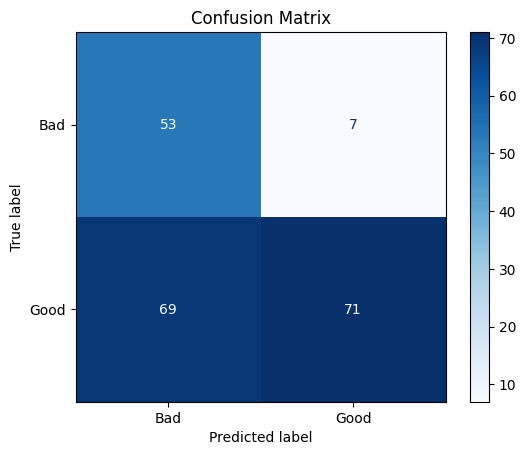

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Tạo confusion matrix
labels = ["Bad", "Good"]
print("confusion matrix", cm)

import matplotlib.pyplot as plt
# Hiển thị ma trận nhầm lẫn
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()


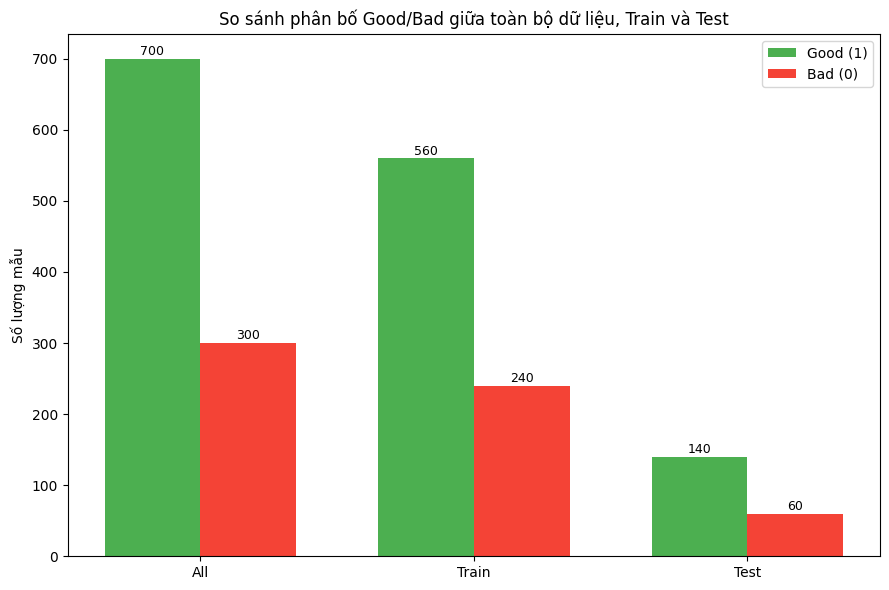

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
#  Dữ liệu nhãn
# ---------------------------------------------------------
y_all = y  # toàn bộ dữ liệu trước khi chia

# Đếm số mẫu good/bad
def count_labels(y):
    unique, counts = np.unique(y, return_counts=True)
    result = dict(zip(unique, counts))
    return result.get(0, 0), result.get(1, 0)  # (bad, good)

bad_all, good_all = count_labels(y_all)
bad_train, good_train = count_labels(y_train)
bad_test, good_test = count_labels(y_test)

# ---------------------------------------------------------
#  Chuẩn bị dữ liệu biểu đồ
# ---------------------------------------------------------
labels = ["All", "Train", "Test"]
bad_values  = [bad_all, bad_train, bad_test]
good_values = [good_all, good_train, good_test]

x = np.arange(len(labels))          # vị trí 3 nhóm cột
width = 0.35                        # độ rộng mỗi cột

# ---------------------------------------------------------
#  Vẽ biểu đồ
# ---------------------------------------------------------
plt.figure(figsize=(9, 6))

plt.bar(x - width/2, good_values, width, label='Good (1)', color='#4CAF50')
plt.bar(x + width/2, bad_values,  width, label='Bad (0)',  color='#F44336')

plt.ylabel("Số lượng mẫu")
plt.title("So sánh phân bố Good/Bad giữa toàn bộ dữ liệu, Train và Test")
plt.xticks(x, labels)
plt.legend()

# Hiển thị giá trị trên từng cột
for i in range(len(labels)):
    plt.text(x[i] - width/2, good_values[i] + 5, str(good_values[i]), ha='center', fontsize=9)
    plt.text(x[i] + width/2, bad_values[i] + 5,  str(bad_values[i]), ha='center', fontsize=9)

plt.tight_layout()
plt.show()
